In [1]:
# Imports and load model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
from sklearn.preprocessing import LabelEncoder

print("SHAP version:", shap.__version__)

model         = joblib.load('../model.pkl')
feature_names = joblib.load('../feature_names.pkl')
print("Model and features loaded")
print(f"Features: {len(feature_names)}")

d:\POWERBI\Attrition_predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.45.0
Model and features loaded
Features: 30


In [2]:
# Rebuild X_test (same preprocessing as model notebook)
df = pd.read_csv('../data/HR-Employee-Attrition.csv')
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

from sklearn.model_selection import train_test_split
X = df.drop('Attrition', axis=1)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_test shape:", X_test.shape)

X_test shape: (294, 30)


In [3]:
#  Create SHAP explainer
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Ready for plots")

SHAP values shape: (294, 30)
Ready for plots


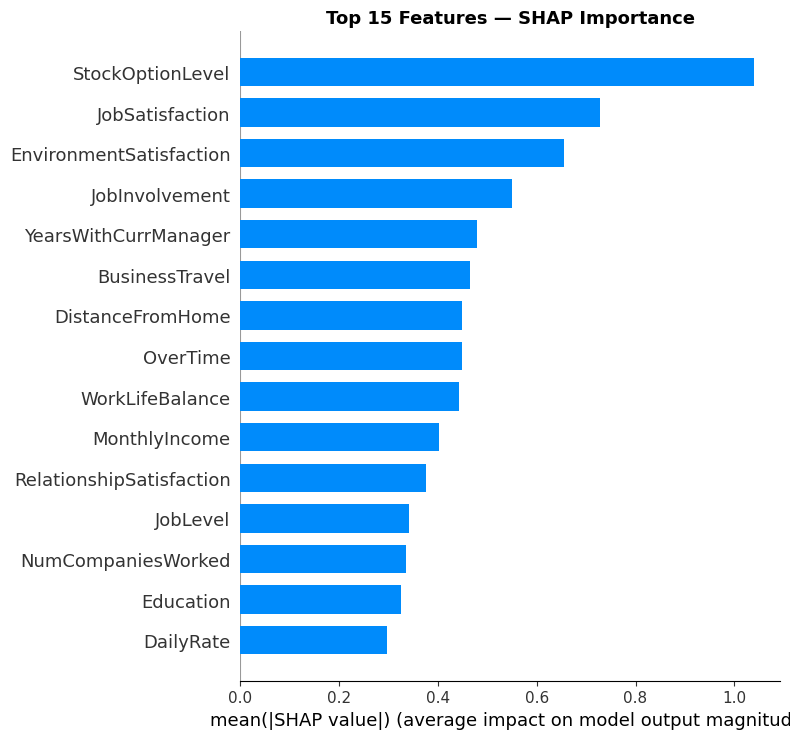

Saved: shap_importance.png


In [4]:
# Global feature importance bar chart (save for README)
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 Features — SHAP Importance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_importance.png")

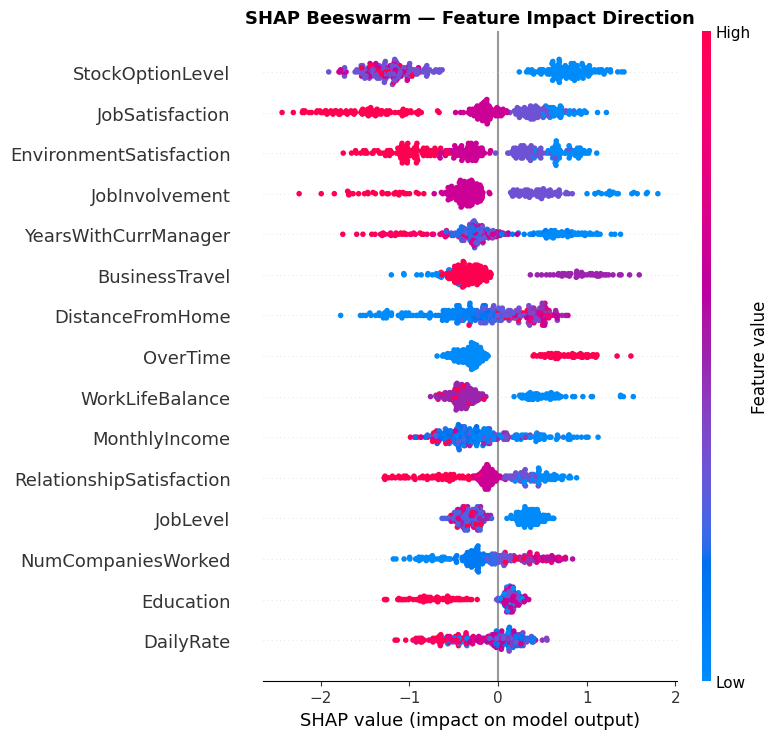

Saved: shap_beeswarm.png


In [5]:
# Beeswarm plot (shows direction of impact)
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact Direction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_beeswarm.png")
# Red = high feature value pushes toward attrition
# Blue = low feature value

In [6]:
# Explain one high-risk employee prediction
# Find an employee the model flagged as high attrition risk
y_pred_proba = model.predict_proba(X_test)[:, 1]
high_risk_idx = y_pred_proba.argmax()  # highest predicted risk

print(f"Highest risk employee (test index {high_risk_idx})")
print(f"Predicted attrition probability: {y_pred_proba[high_risk_idx]*100:.1f}%")
print(f"Actual label: {'Left' if y_test.iloc[high_risk_idx]==1 else 'Stayed'}")
print("\nEmployee profile:")
print(X_test.iloc[high_risk_idx])

Highest risk employee (test index 95)
Predicted attrition probability: 99.6%
Actual label: Left

Employee profile:
Age                            25
BusinessTravel                  2
DailyRate                     383
Department                      2
DistanceFromHome                9
Education                       2
EducationField                  1
EnvironmentSatisfaction         1
Gender                          1
HourlyRate                     68
JobInvolvement                  2
JobLevel                        1
JobRole                         8
JobSatisfaction                 1
MaritalStatus                   1
MonthlyIncome                4400
MonthlyRate                 15182
NumCompaniesWorked              3
OverTime                        0
PercentSalaryHike              12
PerformanceRating               3
RelationshipSatisfaction        1
StockOptionLevel                0
TotalWorkingYears               6
TrainingTimesLastYear           2
WorkLifeBalance                 3
Y

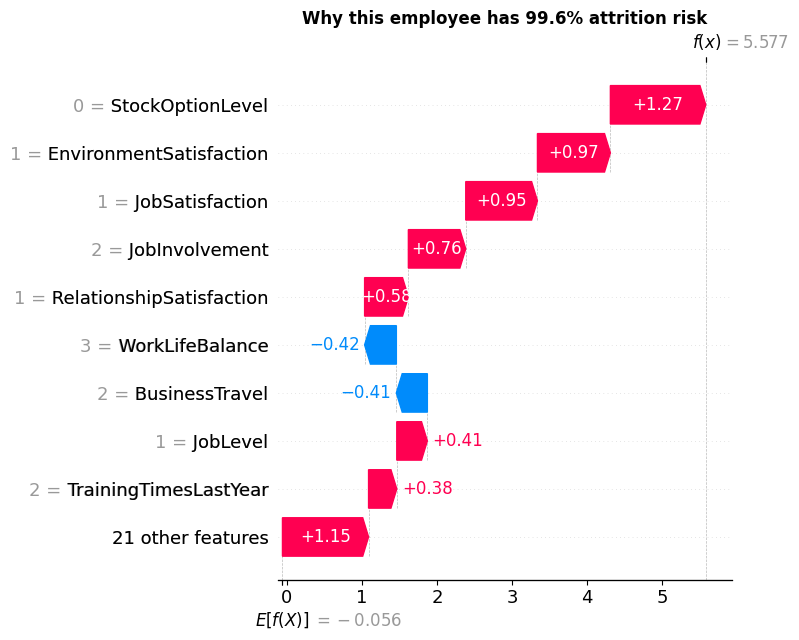

Saved: shap_waterfall.png


In [7]:
# Force plot for that employee (the "wow" chart)
shap.initjs()

# Waterfall plot — cleaner than force plot in notebook
shap.plots.waterfall(
    shap.Explanation(
        values      = shap_values[high_risk_idx],
        base_values = explainer.expected_value,
        data        = X_test.iloc[high_risk_idx].values,
        feature_names = feature_names
    ),
    show=False
)
plt.title(f"Why this employee has {y_pred_proba[high_risk_idx]*100:.1f}% attrition risk",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall.png")

In [8]:
# Print top 3 risk factors (what the Streamlit app will show)
sv       = shap_values[high_risk_idx]
feat_imp = list(zip(feature_names, sv))
feat_imp.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"Top 3 reasons this employee is at risk:\n")
for i, (feat, val) in enumerate(feat_imp[:3], 1):
    direction = "increases" if val > 0 else "decreases"
    print(f"  {i}. {feat}: SHAP={val:.3f} — {direction} attrition risk")

print("\nThese 3 factors will display in your Streamlit app per prediction.")

Top 3 reasons this employee is at risk:

  1. StockOptionLevel: SHAP=1.269 — increases attrition risk
  2. EnvironmentSatisfaction: SHAP=0.970 — increases attrition risk
  3. JobSatisfaction: SHAP=0.954 — increases attrition risk

These 3 factors will display in your Streamlit app per prediction.
